В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [55]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import lightgbm as lgb
from functools import partial

In [51]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 2.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.3 MB/s eta 0:00:00


In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [27]:
raw_df = pd.read_csv('train.csv', index_col=0)
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'
train_df, val_df = split_train_val(raw_df, target_col)
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [29]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [161]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=35,
    enable_categorical=True,  
    use_label_encoder=False, 
    missing=np.nan, 
)

In [163]:
xgb_clf.fit(train_inputs, train_targets)

train_pred = xgb_clf.predict_proba(train_inputs)
val_pred = xgb_clf.predict_proba(val_inputs)

print("train AUROC", roc_auc_score(train_targets, train_pred[:, 1]))
print("val AUROC", roc_auc_score(val_targets, val_pred[:, 1]))

train AUROC 0.9434665790597995
val AUROC 0.937550243500926


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:16:40] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Вау, це найкращі результати, що я бачила на цих даних
Але на кагл вони просідають :)
Трошки є перенавчання, але це не критично

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [42]:
!pip install hyperopt

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 1.8 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.6 MB 2.1 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.7 MB/s eta 0:00:00


In [111]:
def objective(params, model_class):
    clf = model_class(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'], 
        subsample=params['subsample'], 
        colsample_bytree=params['colsample_bytree'], 
        gamma=params['gamma'],  
        reg_alpha=params['reg_alpha'],  
        reg_lambda=params['reg_lambda'], 
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        early_stopping_rounds=10,
        random_state=42,
        device='cuda'
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    pred = clf.predict_proba(val_inputs)
    auroc = roc_auc_score(val_targets, pred[:, 1])

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()

xgb_objective = partial(objective, model_class=xgb.XGBClassifier)
best = fmin(fn=xgb_objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    random_state=42,
    device='cuda'
)

final_clf.fit(train_inputs, train_targets)
final_pred = final_clf.predict_proba(val_inputs)
final_auroc = roc_auc_score(val_targets, final_pred[:, 1])
print("Точність на валідаційній вибірці: {:.4f}".format(final_auroc))

  5%|██▍                                             | 1/20 [00:00<00:02,  8.66trial/s, best loss: -0.9347252898003978]

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:00] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:00] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 15%|███████▏                                        | 3/20 [00:00<00:01,  9.78trial/s, best loss: -0.9347252898003978]

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 20%|█████████▊                                       | 4/20 [00:00<00:02,  7.36trial/s, best loss: -0.934738322244324]

...

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:03] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:03] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:03] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:03] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 95%|████████████████████████████████████████████▋  | 19/20 [00:03<00:00,  6.04trial/s, best loss: -0.9359709170725016]

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:04] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:04] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:04] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:04] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



100%|███████████████████████████████████████████████| 20/20 [00:03<00:00,  5.38trial/s, best loss: -0.9359709170725016]
Найкращі гіперпараметри:  {'colsample_bytree': 0.9559381325242837, 'gamma': 0.1883882496371011, 'learning_rate': 0.13173495051598713, 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 50, 'reg_alpha': 0.4872554419446976, 'reg_lambda': 0.5336902205950577, 'subsample': 0.8633126686917268}
Точність на валідаційній вибірці: 0.9350


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:04] WARNING: D:\bld\xgboost-split_1737531313485\work\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:47:04] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Трошкі гірші результати ніж в минулому завданні, але вдалося позбутися перенавчання

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [114]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень 
    random_state=42,
)

lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

train_pred = lgb_clf.predict_proba(train_inputs)
val_pred = lgb_clf.predict_proba(val_inputs)

print("train AUROC", roc_auc_score(train_targets, train_pred[:, 1]))
print("val AUROC", roc_auc_score(val_targets, val_pred[:, 1]))


train AUROC 0.9388081155971929
val AUROC 0.9362229919747582


Ця модель ще точніша, але трошки перенавчається. 

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [119]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        random_state=42,
        verbose=-1,
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])
    pred = clf.predict_proba(val_inputs)
    auroc = roc_auc_score(val_targets, pred[:, 1])

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    random_state=42,
)

final_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])
final_pred = final_clf.predict_proba(val_inputs)
final_auroc = roc_auc_score(val_targets, final_pred[:, 1])
print("Точність на валідаційній вибірці: {:.4f}".format(final_auroc))

100%|███████████████████████████████████████████████| 10/10 [00:02<00:00,  4.18trial/s, best loss: -0.9356416763838398]
Найкращі гіперпараметри:  {'colsample_bytree': 0.6674458229945994, 'learning_rate': 0.06448283097377032, 'max_depth': 14, 'min_child_weight': 9, 'min_split_gain': 0.052711466513383945, 'n_estimators': 75, 'num_leaves': 69, 'reg_alpha': 0.902044677034008, 'reg_lambda': 0.49562306980465753, 'subsample': 0.9683403484863748}
Точність на валідаційній вибірці: 0.9356


6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [135]:
test_raw_df = pd.read_csv('test.csv')
test_inputs = test_raw_df[input_cols]
test_inputs[cat_features] = test_inputs[cat_features].astype('category')
test_inputs['Exited'] = final_clf.predict_proba(test_inputs)[:, 1]
test_inputs

C:\Users\hp\AppData\Local\Temp\ipykernel_45944\2703990505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_inputs[cat_features] = test_inputs[cat_features].astype('category')
C:\Users\hp\AppData\Local\Temp\ipykernel_45944\2703990505.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_inputs['Exited'] = final_clf.predict_proba(test_inputs)[:, 1]


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.050783
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.021342
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.057787
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.556513
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.026974
...,...,...,...,...,...,...,...,...,...,...,...
9995,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.027083
9996,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.023446
9997,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.008482
9998,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.066073


In [139]:
submission = pd.read_csv('sample_submission.csv')
submission['Exited'] = test_inputs['Exited'].values
submission.to_csv('submission_log_reg.csv', index=False)

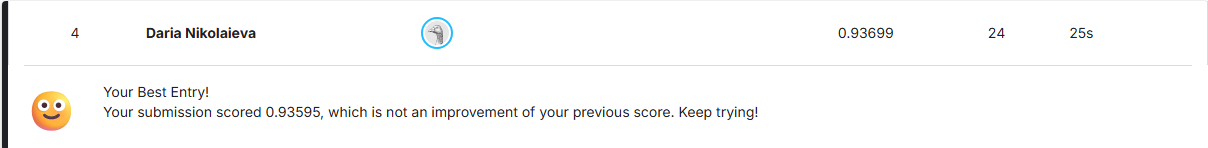

Обрала модель яка показала найкращі результати, хоча вона так і не переплюнула логістичну регресію, можливо, потрібно якісніше протюнити гіперпараметри